<h1 style="text-align:center;">ESCUELA POLITÉCNICA NACIONAL</h1>
<h2 style="text-align:center;">FACULTAD DE INGENIERÍA DE SISTEMAS</h2>
<h3 style="text-align:center;">INGENIERÍA EN COMPUTACIÓN</h3>


**PERÍODO ACADÉMICO:** 2025-B  
**ASIGNATURA:** ICCD412 Métodos Numéricos  
**GRUPO:** GR2  
**TIPO DE INSTRUMENTO:** PROYECTO SEGUNDO BIMESTRE  
**FECHA DE ENTREGA LÍMITE:** 05/02/2026  
**ALUMNO:** Nicolás Yugsi, Sebastián Bravo, Erick Toapanta, Heidy Tenelema.


### FASE 1: Preprocesamiento, Aritmética y Linealización Temporal

En esta primera etapa, preparamos el dataset para que sea apto para el análisis numérico. Los desafíos identificados son:

*   **Formato de Datos:** Los precios se encuentran en formato de texto con separadores de miles innecesarios.
*   **Aritmética de Punto Flotante:** Convertiremos los valores al estándar **IEEE 754 (float64)** para garantizar que los errores de redondeo en cálculos futuros (como derivadas o integrales) sean mínimos.
*   **Variable Independiente:** Los modelos matemáticos requieren un eje numérico. Crearemos la variable $t$, donde cada unidad representa una hora de mercado.


In [27]:
#@title FASE 1: Carga, Inspección y Preprocesamiento
import pandas as pd
import numpy as np

# --- 1. CARGA INICIAL Y RECONOCIMIENTO DEL DATASET ---
archivo = 'CRYPTO_BTC_USD.csv'

def cargar_y_limpiar_datos(path):
    """Función de carga armonizada con el informe"""
    df = pd.read_csv(path, sep=';')
    df['open_time'] = pd.to_datetime(df['open_time']).dt.tz_localize(None)
    return df

try:
    df_total = cargar_y_limpiar_datos(archivo)
    limite_minimo = df_total['open_time'].min()
    limite_maximo = df_total['open_time'].max()

    print("INFORMACION DEL DATASET CARGADO")
    print(f"Inicio del registro histórico: {limite_minimo}")
    print(f"Fin del registro histórico:    {limite_maximo}")
    print(f"Total de registros:            {len(df_total)}")
    print("-" * 50)

except Exception as e:
    print(f"ERROR CRITICO AL CARGAR EL DATASET: {e}")

# --- 2. DEFINICIÓN DE PARÁMETROS DE USUARIO ---
fecha_inicio_usuario = '2017-08-20' #@param {type:"string"}
fecha_fin_usuario    = '2017-08-30' #@param {type:"string"}

# --- 3. VALIDACIÓN Y SEGMENTACIÓN DE DATOS ---
try:
    inicio_dt = pd.to_datetime(fecha_inicio_usuario)
    fin_dt    = pd.to_datetime(fecha_fin_usuario)

    if inicio_dt < limite_minimo or fin_dt > limite_maximo:
        print("ERROR DE RANGO: Las fechas seleccionadas están fuera del historial disponible.")
    elif inicio_dt >= fin_dt:
        print("ERROR LÓGICO: La fecha de inicio debe ser anterior a la fecha final.")
    else:
        mascara = (df_total['open_time'] >= inicio_dt) & (df_total['open_time'] <= fin_dt)
        df_analisis = df_total.loc[mascara].copy()

        # --- 4. LIMPIEZA Y TRANSFORMACIÓN IEEE 754 ---
        def normalizar_valor(texto):
            if isinstance(texto, str):
                return float(texto.replace('.', '')) / 100000000
            return texto

        columnas_precio = ['open_price', 'high_price', 'low_price', 'close_price']
        for col in columnas_precio:
            df_analisis[col] = df_analisis[col].apply(normalizar_valor)

        # Generación de variable independiente t (armonizado con flujograma)
        df_analisis['t'] = np.arange(len(df_analisis))

        print("\nPROCESAMIENTO DE DATOS COMPLETADO")
        print(f"Ventana de análisis: {inicio_dt.date()} a {fin_dt.date()}")
        print(f"Puntos (n) para cálculo numérico: {len(df_analisis)}")
        print("\nMuestra de las primeras filas procesadas:")
        print(df_analisis[['open_time', 't', 'close_price']].head())

except Exception as e:
    print(f"ERROR EN EL PROCESAMIENTO: {e}")

INFORMACION DEL DATASET CARGADO
Inicio del registro histórico: 2017-08-18 13:00:00
Fin del registro histórico:    2018-10-11 19:00:00
Total de registros:            10000
--------------------------------------------------

PROCESAMIENTO DE DATOS COMPLETADO
Ventana de análisis: 2017-08-20 a 2017-08-30
Puntos (n) para cálculo numérico: 241

Muestra de las primeras filas procesadas:
             open_time  t  close_price
35 2017-08-20 00:00:00  0      4086.09
36 2017-08-20 01:00:00  1      4082.53
37 2017-08-20 02:00:00  2      4124.69
38 2017-08-20 03:00:00  3      4094.62
39 2017-08-20 04:00:00  4      4093.00


## FASE 2: Representación de la Dinámica del Precio y Rango de Volatilidad

En esta fase visualizamos el segmento de datos seleccionado para entender la relación entre el tiempo lineal ($t$) y la variación del precio en USD.

**Interpretación Técnica:**
1. **Escala Temporal:** El eje horizontal representa las horas transcurridas desde el inicio del intervalo ($t=0$). Un valor de 3500 indica que se están analizando 3500 horas de mercado.
2. **Túnel de Incertidumbre:** La franja sombreada representa el área entre el precio máximo y mínimo de cada hora. Su grosor indica visualmente la volatilidad: a mayor grosor, mayor riesgo y dificultad para el modelado numérico.
3. **Trayectoria de Cierre:** La línea central es el precio de cierre, que utilizaremos como base para nuestras futuras estimaciones.

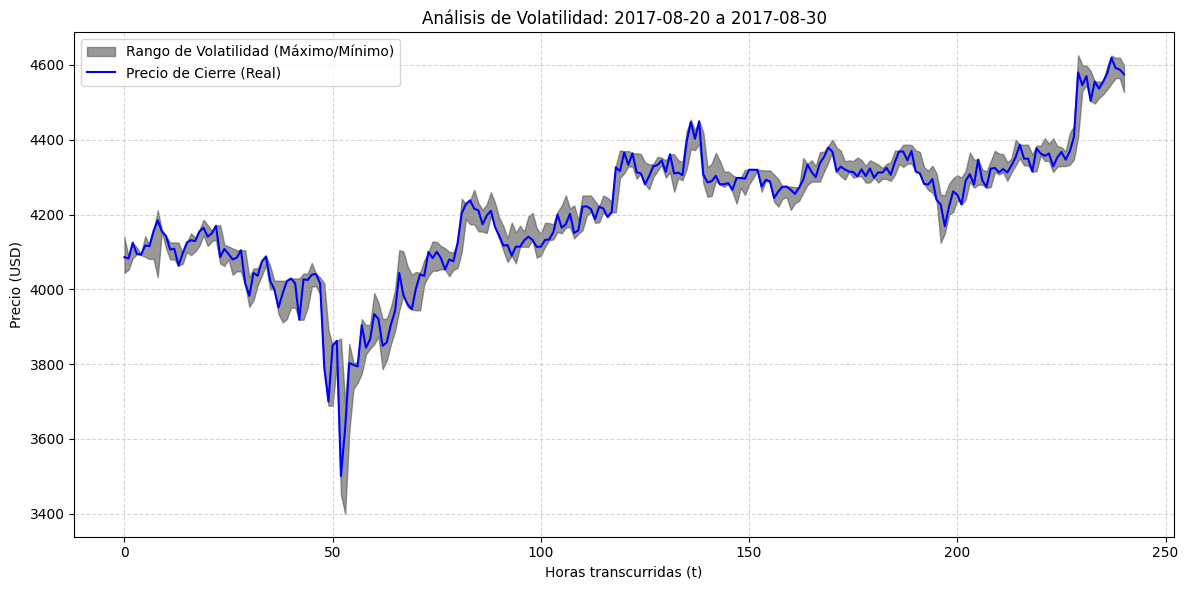

ESTADÍSTICAS DEL PERIODO:
- Total de horas (t_max): 240
- Precio Mínimo registrado: $3,400.00
- Precio Máximo registrado: $4,625.85


In [28]:
#@title FASE 2: Análisis de Volatilidad
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.fill_between(
    df_analisis['t'],
    df_analisis['low_price'],
    df_analisis['high_price'],
    color='#555555',
    alpha=0.6,
    label='Rango de Volatilidad (Máximo/Mínimo)'
)

plt.plot(
    df_analisis['t'],
    df_analisis['close_price'],
    color='blue',
    linewidth=1.5,
    label='Precio de Cierre (Real)'
)

plt.title(f'Análisis de Volatilidad: {inicio_dt.date()} a {fin_dt.date()}')
plt.xlabel('Horas transcurridas (t)')
plt.ylabel('Precio (USD)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

margen_y = (df_analisis['high_price'].max() - df_analisis['low_price'].min()) * 0.05
plt.ylim(df_analisis['low_price'].min() - margen_y, df_analisis['high_price'].max() + margen_y)

plt.tight_layout()
plt.show()

print("ESTADÍSTICAS DEL PERIODO:")
print(f"- Total de horas (t_max): {df_analisis['t'].max()}")
print(f"- Precio Mínimo registrado: ${df_analisis['low_price'].min():,.2f}")
print(f"- Precio Máximo registrado: ${df_analisis['high_price'].max():,.2f}")

## FASE 3: Modelado de Tendencia mediante Regresión por Mínimos Cuadrados

En esta fase, transformamos los datos discretos del precio en una función continua $f(t)$ que represente la tendencia principal del mercado. Para ello, aplicamos el método de **Mínimos Cuadrados**.

**Fundamento Matemático:**
El objetivo es encontrar los coeficientes de un polinomio de grado $n$ que minimice la suma de los cuadrados de las diferencias (residuos) entre los precios reales ($y_i$) y los valores calculados por nuestra función ($f(t_i)$):

$$\min \sum_{i=0}^{m} [y_i - f(t_i)]^2$$

**Utilidad en el Proyecto:**
1. **Reducción de Ruido:** Filtramos las fluctuaciones aleatorias del mercado para identificar la dirección estructural del precio.
2. **Obtención de una Ecuación:** Generamos una expresión matemática analítica que nos permitirá realizar estimaciones fuera del rango de datos actual.
3. **Análisis de Aceleración:** Dependiendo del grado del polinomio (lineal o cuadrático), podremos determinar no solo la dirección, sino si el movimiento del precio se está acelerando o desacelerando.

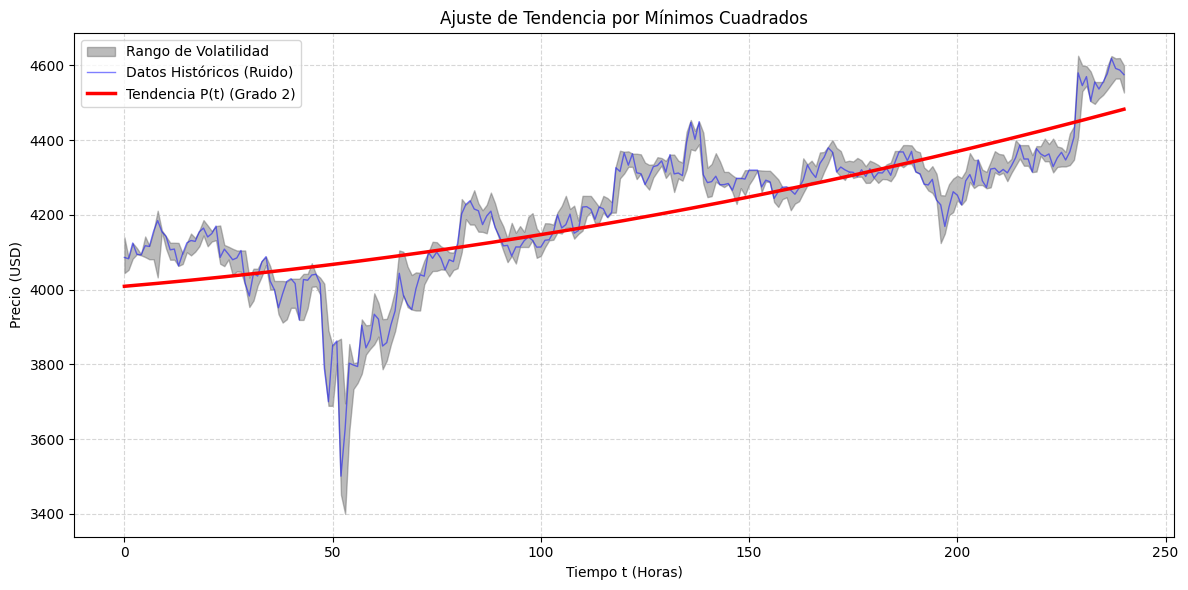

--- RESULTADOS DEL MODELADO ---
Coeficiente R2: 0.6158
Ecuación Polinomial P(t):
          2
0.004226 x + 0.9598 x + 4009


In [29]:
#@title FASE 3: Modelado de Tendencia (Regresión por Mínimos Cuadrados)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# @markdown Seleccione el grado del polinomio (1: Lineal, 2: Cuadrático, 3: Cúbico):
grado_n = 3 #@param {type:"slider", min:1, max:3, step:1}

t = df_analisis['t'].values
y = df_analisis['close_price'].values

# Mínimos cuadrados para hallar coeficientes
coef = np.polyfit(t, y, grado_n)

# Construcción de la función P(t) mencionada en el informe
P_t = np.poly1d(coef)
y_tendencia = P_t(t)

# Cálculo de precisión para el reporte
precision_r2 = r2_score(y, y_tendencia)

plt.figure(figsize=(12, 6))

plt.fill_between(t, df_analisis['low_price'], df_analisis['high_price'], color='#555555', alpha=0.4, label='Rango de Volatilidad')
plt.plot(t, y, color='blue', alpha=0.5, linewidth=1, label='Datos Históricos (Ruido)')
plt.plot(t, y_tendencia, color='red', linewidth=2.5, label=f'Tendencia P(t) (Grado {grado_n})')

plt.title(f'Ajuste de Tendencia por Mínimos Cuadrados')
plt.xlabel('Tiempo t (Horas)')
plt.ylabel('Precio (USD)')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("--- RESULTADOS DEL MODELADO ---")
print(f"Coeficiente R2: {precision_r2:.4f}")
print(f"Ecuación Polinomial P(t):")
print(P_t)

## FASE 4: Interpolación y Suavizado mediante Splines Cúbicos

En esta fase, aplicamos la interpolación por **Splines Cúbicos** para obtener una función continua $S(t)$ que represente fielmente la trayectoria del precio.

**Fundamento Matemático:**
A diferencia de los polinomios globales, los Splines cúbicos se definen por tramos, garantizando la continuidad de la función y de sus dos primeras derivadas ($S'(t)$ y $S''(t)$). Esto evita las oscilaciones artificiales (Fenómeno de Runge) y proporciona una curva suave que es analíticamente derivable.

**Ventajas Técnicas:**
1. **Fidelidad de Datos:** La curva intercepta todos los puntos observados de la serie temporal.
2. **Derivabilidad:** La suavidad de la curva permite el cálculo preciso de la tasa de variación del precio.
3. **Validación:** Se comparará esta interpolación con el túnel de volatilidad para confirmar que el suavizado no distorsiona la realidad del mercado.

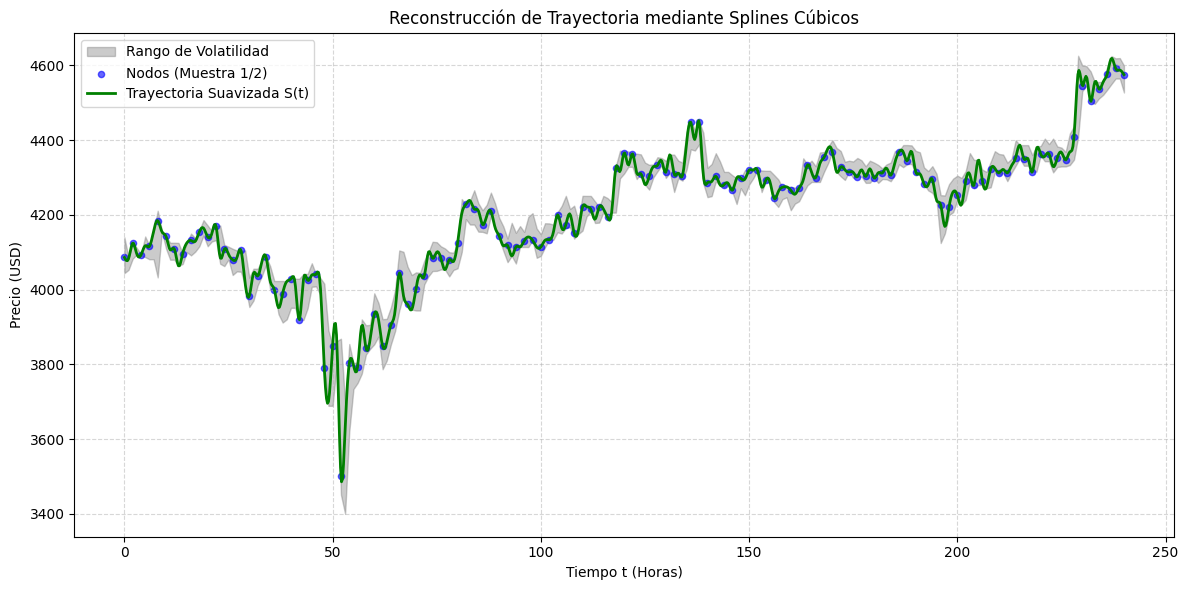

--- ANÁLISIS DE LA INTERPOLACIÓN ---
Total de nodos procesados: 241
Velocidad alcista máx (S'(t)): +$250.75 USD/h


In [30]:
#@title FASE 4: Interpolación y Suavizado (Splines Cúbicos)
from scipy.interpolate import CubicSpline
import numpy as np
import matplotlib.pyplot as plt

t = df_analisis['t'].values
y = df_analisis['close_price'].values
n_total = len(t)

# Cálculo del spline natural (S(t) en el informe)
spline = CubicSpline(t, y, bc_type='natural')

t_suave = np.linspace(t.min(), t.max(), 1000)
y_spline = spline(t_suave)

# Dinámica del mercado basada en spline(t, 1)
velocidad = spline(t, 1)

if n_total > 200:
    paso_visual = int(n_total / 100)
    etiqueta_puntos = f'Nodos (Muestra 1/{paso_visual})'
else:
    paso_visual = 1
    etiqueta_puntos = 'Nodos (Todos)'

plt.figure(figsize=(12, 6))
plt.fill_between(t, df_analisis['low_price'], df_analisis['high_price'], color='#555555', alpha=0.3, label='Rango de Volatilidad')
plt.scatter(t[::paso_visual], y[::paso_visual], color='blue', s=20, alpha=0.6, label=etiqueta_puntos)
plt.plot(t_suave, y_spline, color='green', linewidth=2, label='Trayectoria Suavizada S(t)')

plt.title(f'Reconstrucción de Trayectoria mediante Splines Cúbicos')
plt.xlabel('Tiempo t (Horas)')
plt.ylabel('Precio (USD)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("--- ANÁLISIS DE LA INTERPOLACIÓN ---")
print(f"Total de nodos procesados: {n_total}")
print(f"Velocidad alcista máx (S'(t)): +${velocidad.max():.2f} USD/h")

## FASE 5: Estimación de Precios mediante Búsqueda de Raíces

En esta fase final, utilizamos la función continua $S(t)$ obtenida mediante Splines para estimar el momento exacto en el que el activo alcanzará un valor objetivo.

**Fundamento Matemático:**
Se define una función de error $g(t) = S(t) - P_{objetivo}$. El problema consiste en hallar la raíz $t^*$ tal que $g(t^*) = 0$. Para ello, empleamos el **Método de Newton-Raphson**, el cual utiliza la información de la derivada de la curva para converger de forma iterativa hacia la solución:

$$t_{n+1} = t_n - \frac{g(t_n)}{g'(t_n)}$$

**Finalidad Técnica:**
Proporcionar una estimación basada en el modelo matemático de interpolación, permitiendo proyectar resultados más allá de la observación visual directa.

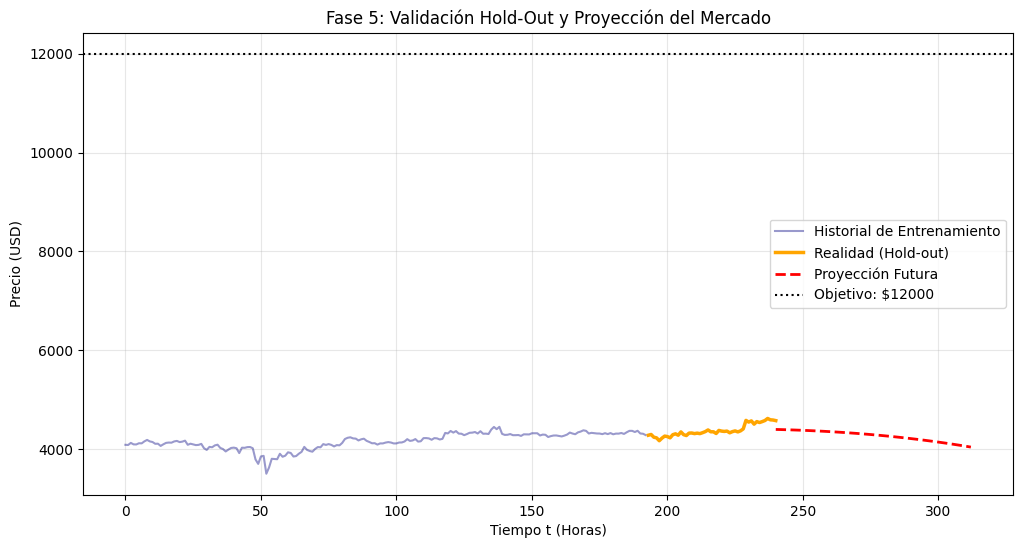

--- REPORTE FINAL DE CALIDAD ---
Error Absoluto (RMSE): $530.65 USD
ERROR RELATIVO: 12.12%
ANÁLISIS DE PRECISIÓN: Aceptable
--------------------------------------------------
Precio objetivo de prueba colocado: $12,000.00 USD
Diferencia actual respecto al objetivo: $7,424.77 USD
--------------------------------------------------
RECOMENDACIÓN FINAL: NO RECOMENDADO: El objetivo es divergente o la fiabilidad es insuficiente.


In [32]:
#@title FASE 5: Reporte Final de Métricas y Recomendación
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- 1. CONFIGURACIÓN Y PARÁMETROS DE ENTRADA ---
# Parámetro solicitado para definir la meta financiera
precio_objetivo = 12000 #@param {type:"number"}
n_prueba = 48  # Tamaño del bloque Hold-out (últimas 48 horas)

# Slicing (recorte) de datos armonizado con el informe
df_entrenamiento = df_analisis.iloc[:-n_prueba]
df_prueba = df_analisis.iloc[-n_prueba:]

# --- 2. CÁLCULOS TÉCNICOS (Validación y Proyección) ---
# Modelo para validar (entrenado solo con el historial pasado)
coef_val = np.polyfit(df_entrenamiento['t'], df_entrenamiento['close_price'], 3)
modelo_val = np.poly1d(coef_val)

# Modelo para proyectar (entrenado con el 100% de los datos para mayor precisión)
# Se utiliza el polinomio P(t) definido en la Fase 3
coef_proy = np.polyfit(df_analisis['t'], df_analisis['close_price'], 3)
P_t_proyeccion = np.poly1d(coef_proy)

# --- 3. MÉTRICAS DE ERROR (mean_squared_error) ---
# Comparación vectorial de la Realidad Oculta vs Proyectado
precios_reales_ocultos = df_prueba['close_price'].values
precios_proyectados = modelo_val(df_prueba['t'].values)

# RMSE: Error Cuadrático Medio armonizado con el reporte
error_promedio_rmse = np.sqrt(mean_squared_error(precios_reales_ocultos, precios_proyectados))
precio_medio = precios_reales_ocultos.mean()
error_relativo = (error_promedio_rmse / precio_medio) * 100
distancia_al_objetivo = precio_objetivo - df_analisis['close_price'].iloc[-1]

# --- 4. VISUALIZACIÓN GRÁFICA ---
plt.figure(figsize=(12, 6))

# Historial (Azul)
plt.plot(df_entrenamiento['t'], df_entrenamiento['close_price'],
         color='navy', alpha=0.4, label='Historial de Entrenamiento')

# Realidad Oculta / Hold-out (Naranja)
plt.plot(df_prueba['t'], precios_reales_ocultos,
         color='orange', linewidth=2.5, label='Realidad (Hold-out)')

# Proyección Futura (Línea Roja - Uso de np.linspace)
t_final = df_analisis['t'].max()
t_futuro = np.linspace(t_final, t_final + (n_prueba * 1.5), 50)
plt.plot(t_futuro, P_t_proyeccion(t_futuro),
         color='red', linestyle='--', linewidth=2, label='Proyección Futura')

# Línea de Objetivo (Precio deseado)
plt.axhline(y=precio_objetivo, color='black', linestyle=':', label=f'Objetivo: ${precio_objetivo}')

plt.title('Fase 5: Validación Hold-Out y Proyección del Mercado')
plt.xlabel('Tiempo t (Horas)')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. REPORTE DE RESULTADOS ---
print("--- REPORTE FINAL DE CALIDAD ---")
print(f"Error Absoluto (RMSE): ${error_promedio_rmse:,.2f} USD")
print(f"ERROR RELATIVO: {error_relativo:.2f}%")
print(f"ANÁLISIS DE PRECISIÓN: {'Alta' if error_relativo < 5 else 'Aceptable' if error_relativo < 15 else 'Baja'}")
print("-" * 50)
print(f"Precio objetivo de prueba colocado: ${precio_objetivo:,.2f} USD")
print(f"Diferencia actual respecto al objetivo: ${distancia_al_objetivo:,.2f} USD")
print("-" * 50)

# Lógica de Recomendación Final
precio_estimado_proximo = P_t_proyeccion(t_final + 24)
va_hacia_objetivo = False

if distancia_al_objetivo > 0: # El objetivo es que suba
    if precio_estimado_proximo > df_analisis['close_price'].iloc[-1]:
        va_hacia_objetivo = True
else: # El objetivo es que baje
    if precio_estimado_proximo < df_analisis['close_price'].iloc[-1]:
        va_hacia_objetivo = True

if error_relativo < 15 and va_hacia_objetivo:
    print("RECOMENDACIÓN FINAL: RECOMENDADO: El objetivo es coherente con la inercia del modelo.")
else:
    print("RECOMENDACIÓN FINAL: NO RECOMENDADO: El objetivo es divergente o la fiabilidad es insuficiente.")